
# GASGUARD - LPG DEPLETION PREDICTION
# MULTIPLE LINEAR REGRESSION TRAINING
#

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import libraries

In [ ]:
import os
import time
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

warnings.filterwarnings("ignore")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


LOAD DATASET

In [ ]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for name in uploaded.keys():
    print("✓", name)

Saving train_dataset.csv to train_dataset.csv
Uploaded files:
✓ train_dataset.csv


Import libraries

In [82]:
import os
import time
import json
import pickle
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    KFold
)

from sklearn.preprocessing import (
    StandardScaler,
    PolynomialFeatures
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

warnings.filterwarnings("ignore")

OUTPUT_DIR = "GasGuard_ML_Final"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("✓ Libraries imported successfully")
print("✓ Output folder created")

✓ Libraries imported successfully
✓ Output folder created


Load the dataset

In [83]:
dataset_path = "train_dataset.csv"

df = pd.read_csv(dataset_path)

if "date" in df.columns:
    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )

print("=" * 75)
print("GASGUARD LPG DEPLETION DATASET")
print("=" * 75)

print(f"Total Records : {len(df)}")
print(f"Total Columns : {len(df.columns)}")

print("\nDataset Columns:")

for i, col in enumerate(df.columns, 1):
    print(f"{i:02d}. {col}")

print("\nFirst 10 Records:")

display(
    df.head(10)
)

GASGUARD LPG DEPLETION DATASET
Total Records : 180
Total Columns : 15

Dataset Columns:
01. date
02. gas_weight_kg
03. daily_usage_kg
04. cylinder_type
05. gas_percentage
06. days_since_refill
07. day_of_week
08. weekend
09. consumption_rate
10. usage_velocity
11. rolling_avg_7
12. days_remaining
13. refill_price_lkr
14. price_per_kg_lkr
15. estimated_monthly_cost

First 10 Records:


,date,gas_weight_kg,daily_usage_kg,cylinder_type,gas_percentage,days_since_refill,day_of_week,weekend,consumption_rate,usage_velocity,rolling_avg_7,days_remaining,refill_price_lkr,price_per_kg_lkr,estimated_monthly_cost
0,2026-01-01,5.000000,0.072484,5kg Standard,100.000000,0,3,0,0.000725,0.000000,0.083167,60,1910,382,830.661721
1,2026-01-02,4.925691,0.074309,5kg Standard,98.513826,1,4,0,0.000754,0.001825,0.083167,59,1910,382,851.577456
2,2026-01-03,4.842453,0.083238,5kg Standard,96.849058,2,5,1,0.000859,0.008930,0.083167,58,1910,382,953.912553
3,2026-01-04,4.744838,0.097615,5kg Standard,94.896755,3,6,1,0.001029,0.014377,0.083167,57,1910,382,1118.669611
4,2026-01-05,4.646008,0.098829,5kg Standard,92.920170,4,0,0,0.001064,0.001214,0.083167,56,1910,382,1132.583012
5,2026-01-06,4.552179,0.093829,5kg Standard,91.043584,5,1,0,0.001031,-0.005000,0.083167,55,1910,382,1075.283952
6,2026-01-07,4.471283,0.080896,5kg Standard,89.425662,6,2,0,0.000905,-0.012933,0.085886,54,1910,382,927.068894
7,2026-01-08,4.397446,0.073837,5kg Standard,87.948919,7,3,0,0.000840,-0.007059,0.086079,53,1910,382,846.174010
8,2026-01-09,4.324793,0.072653,5kg Standard,86.495866,8,4,0,0.000840,-0.001185,0.085843,52,1910,382,832.599118
9,2026-01-10,4.242081,0.082713,5kg Standard,84.841610,9,5,1,0.000975,0.010060,0.085767,51,1910,382,947.888690


Feature engineering

In [84]:
dataset_path = "train_dataset.csv"

df = pd.read_csv(dataset_path)

if "date" in df.columns:
    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )

print("=" * 75)
print("GASGUARD LPG DEPLETION DATASET")
print("=" * 75)

print(f"Total Records : {len(df)}")
print(f"Total Columns : {len(df.columns)}")

print("\nDataset Columns:")

for i, col in enumerate(df.columns, 1):
    print(f"{i:02d}. {col}")

print("\nFirst 10 Records:")

display(
    df.head(10)
)

GASGUARD LPG DEPLETION DATASET
Total Records : 180
Total Columns : 15

Dataset Columns:
01. date
02. gas_weight_kg
03. daily_usage_kg
04. cylinder_type
05. gas_percentage
06. days_since_refill
07. day_of_week
08. weekend
09. consumption_rate
10. usage_velocity
11. rolling_avg_7
12. days_remaining
13. refill_price_lkr
14. price_per_kg_lkr
15. estimated_monthly_cost

First 10 Records:


,date,gas_weight_kg,daily_usage_kg,cylinder_type,gas_percentage,days_since_refill,day_of_week,weekend,consumption_rate,usage_velocity,rolling_avg_7,days_remaining,refill_price_lkr,price_per_kg_lkr,estimated_monthly_cost
0,2026-01-01,5.000000,0.072484,5kg Standard,100.000000,0,3,0,0.000725,0.000000,0.083167,60,1910,382,830.661721
1,2026-01-02,4.925691,0.074309,5kg Standard,98.513826,1,4,0,0.000754,0.001825,0.083167,59,1910,382,851.577456
2,2026-01-03,4.842453,0.083238,5kg Standard,96.849058,2,5,1,0.000859,0.008930,0.083167,58,1910,382,953.912553
3,2026-01-04,4.744838,0.097615,5kg Standard,94.896755,3,6,1,0.001029,0.014377,0.083167,57,1910,382,1118.669611
4,2026-01-05,4.646008,0.098829,5kg Standard,92.920170,4,0,0,0.001064,0.001214,0.083167,56,1910,382,1132.583012
5,2026-01-06,4.552179,0.093829,5kg Standard,91.043584,5,1,0,0.001031,-0.005000,0.083167,55,1910,382,1075.283952
6,2026-01-07,4.471283,0.080896,5kg Standard,89.425662,6,2,0,0.000905,-0.012933,0.085886,54,1910,382,927.068894
7,2026-01-08,4.397446,0.073837,5kg Standard,87.948919,7,3,0,0.000840,-0.007059,0.086079,53,1910,382,846.174010
8,2026-01-09,4.324793,0.072653,5kg Standard,86.495866,8,4,0,0.000840,-0.001185,0.085843,52,1910,382,832.599118
9,2026-01-10,4.242081,0.082713,5kg Standard,84.841610,9,5,1,0.000975,0.010060,0.085767,51,1910,382,947.888690


Select Features

In [85]:
feature_columns = [

    "gas_weight_kg",
    "gas_percentage",
    "daily_usage_kg",
    "day_of_week",
    "weekend",
    "consumption_rate",
    "usage_velocity",
    "rolling_avg_7",
    "days_since_refill"

]

target_column = "days_remaining"


df = df.dropna(
    subset=
    feature_columns
    + [target_column]
).reset_index(drop=True)


X = df[
    feature_columns
].astype(float)


y = df[
    target_column
].astype(float)


print("=" * 75)
print("FEATURE ENGINEERING & PREPROCESSING")
print("=" * 75)

print("\n✓ Prepared 9 predictive features")

for feature in feature_columns:

    print(
        f"  - {feature}"
    )


print(
    f"\n✓ Feature matrix shape : {X.shape}"
)

print(
    f"✓ Target vector shape  : {y.shape}"
)

print(
    f"✓ Target               : {target_column}"
)

FEATURE ENGINEERING & PREPROCESSING

✓ Prepared 9 predictive features
  - gas_weight_kg
  - gas_percentage
  - daily_usage_kg
  - day_of_week
  - weekend
  - consumption_rate
  - usage_velocity
  - rolling_avg_7
  - days_since_refill

✓ Feature matrix shape : (180, 9)
✓ Target vector shape  : (180,)
✓ Target               : days_remaining


Train/test split and scaling

In [86]:
feature_columns = [

    "gas_weight_kg",
    "gas_percentage",
    "daily_usage_kg",
    "day_of_week",
    "weekend",
    "consumption_rate",
    "usage_velocity",
    "rolling_avg_7",
    "days_since_refill"

]

target_column = "days_remaining"


df = df.dropna(
    subset=
    feature_columns
    + [target_column]
).reset_index(drop=True)


X = df[
    feature_columns
].astype(float)


y = df[
    target_column
].astype(float)


print("=" * 75)
print("FEATURE ENGINEERING & PREPROCESSING")
print("=" * 75)

print("\n✓ Prepared 9 predictive features")

for feature in feature_columns:

    print(
        f"  - {feature}"
    )


print(
    f"\n✓ Feature matrix shape : {X.shape}"
)

print(
    f"✓ Target vector shape  : {y.shape}"
)

print(
    f"✓ Target               : {target_column}"
)

FEATURE ENGINEERING & PREPROCESSING

✓ Prepared 9 predictive features
  - gas_weight_kg
  - gas_percentage
  - daily_usage_kg
  - day_of_week
  - weekend
  - consumption_rate
  - usage_velocity
  - rolling_avg_7
  - days_since_refill

✓ Feature matrix shape : (180, 9)
✓ Target vector shape  : (180,)
✓ Target               : days_remaining


Train/Test + Validation Split

In [88]:
# ============================================================
# 80% TRAINING / 20% FINAL TEST
# ============================================================

X_train_full, X_test, \
y_train_full, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    shuffle=True
)


# ============================================================
# INTERNAL VALIDATION FOR EPOCH TRAINING
# ============================================================

X_train, X_val, \
y_train, y_val = train_test_split(

    X_train_full,
    y_train_full,

    test_size=0.20,

    random_state=42,

    shuffle=True
)


print("=" * 75)
print("DATA SPLIT CONFIGURATION")
print("=" * 75)


print(
    f"Training Set : "
    f"{len(X_train_full)} samples "
    f"({len(X_train_full)/len(X)*100:.1f}%)"
)


print(
    f"Testing Set  : "
    f"{len(X_test)} samples "
    f"({len(X_test)/len(X)*100:.1f}%)"
)


print(
    f"Epoch Train  : "
    f"{len(X_train)}"
)


print(
    f"Validation   : "
    f"{len(X_val)}"
)


print(
    "Random State: 42 (reproducible)"
)

DATA SPLIT CONFIGURATION
Training Set : 144 samples (80.0%)
Testing Set  : 36 samples (20.0%)
Epoch Train  : 115
Validation   : 29
Random State: 42 (reproducible)


Feature Scaling

In [89]:
scaler = StandardScaler()


X_train_scaled = (
    scaler.fit_transform(
        X_train
    )
)


X_val_scaled = (
    scaler.transform(
        X_val
    )
)


print("=" * 75)
print("FEATURE SCALING")
print("=" * 75)


print(
    "Scaler Type : StandardScaler "
    "(mean=0, variance=1)"
)


print(
    "Training Mean :",
    np.round(
        scaler.mean_,
        5
    )
)


print(
    "Training Scale:",
    np.round(
        scaler.scale_,
        5
    )
)


print(
    "\n✓ Feature scaling completed"
)

FEATURE SCALING
Scaler Type : StandardScaler (mean=0, variance=1)
Training Mean : [2.635970e+00 5.271937e+01 8.381000e-02 3.095650e+00 3.130400e-01
 3.230000e-03 9.300000e-04 8.312000e-02 8.847826e+01]
Training Scale: [1.426460e+00 2.852926e+01 1.205000e-02 2.038640e+00 4.637300e-01
 4.950000e-03 1.197000e-02 1.480000e-03 5.301900e+01]

✓ Feature scaling completed


Learning Rate Selection

Learning Rate Search

In [94]:
def evaluate_learning_rate(lr):

    X_b = np.c_[

        np.ones(
            (
                X_train_scaled.shape[0],
                1
            )
        ),

        X_train_scaled
    ]


    X_v = np.c_[

        np.ones(
            (
                X_val_scaled.shape[0],
                1
            )
        ),

        X_val_scaled
    ]


    temp_theta = np.zeros(
        X_b.shape[1]
    )


    y_array = (
        y_train.to_numpy()
    )


    for epoch in range(100):

        prediction = (
            X_b @ temp_theta
        )

        error = (
            prediction
            - y_array
        )

        gradient = (
            2 / len(y_array)
        ) * (
            X_b.T @ error
        )

        temp_theta -= (
            lr * gradient
        )


    val_prediction = (
        X_v @ temp_theta
    )


    mse = mean_squared_error(
        y_val,
        val_prediction
    )


    r2 = r2_score(
        y_val,
        val_prediction
    )


    return mse, r2

Test Learning Rates

In [95]:
learning_rates = [

    0.001,
    0.003,
    0.005,
    0.0073,
    0.01,
    0.03,
    0.05,
    0.10,
    0.20,
    0.30

]


lr_results = []


for lr in learning_rates:

    mse_lr, r2_lr = (
        evaluate_learning_rate(
            lr
        )
    )

    lr_results.append([
        lr,
        mse_lr,
        r2_lr
    ])


lr_table = pd.DataFrame(

    lr_results,

    columns=[
        "Learning Rate",
        "Validation MSE",
        "Validation R²"
    ]
)


lr_table = (
    lr_table
    .sort_values(
        "Validation MSE"
    )
    .reset_index(drop=True)
)


display(
    lr_table.round(6)
)


learning_rate = float(
    lr_table.iloc[0][
        "Learning Rate"
    ]
)


print(
    "\n✓ Selected Learning Rate:",
    learning_rate
)

,Learning Rate,Validation MSE,Validation R²
0,0.0300,4.119876,0.986244
1,0.0500,4.127500,0.986218
2,0.1000,4.370402,0.985407
3,0.2000,4.564228,0.984760
4,0.3000,4.621243,0.984570
5,0.0100,24.453933,0.918348
6,0.0073,58.773943,0.803752
7,0.0050,135.408231,0.547869
8,0.0030,293.594519,0.019681
9,0.0010,684.551182,-1.285733



✓ Selected Learning Rate: 0.03


100-Epoch Training

In [96]:
print("=" * 78)
print("MODEL TRAINING - MULTIPLE LINEAR REGRESSION")
print("=" * 78)


X_train_b = np.c_[

    np.ones(
        (
            X_train_scaled.shape[0],
            1
        )
    ),

    X_train_scaled

]


X_val_b = np.c_[

    np.ones(
        (
            X_val_scaled.shape[0],
            1
        )
    ),

    X_val_scaled

]


theta = np.zeros(
    X_train_b.shape[1]
)


epochs = 100

m = len(
    y_train
)


train_losses = []
val_losses = []

train_r2_history = []
val_r2_history = []

gradient_norms = []
epoch_times = []


start_training = time.time()


for epoch in range(
    1,
    epochs + 1
):


    epoch_start = time.time()


    # --------------------------------
    # Forward Pass
    # --------------------------------

    prediction = (
        X_train_b @ theta
    )


    error = (
        prediction
        - y_train.to_numpy()
    )


    # --------------------------------
    # Gradient
    # --------------------------------

    gradient = (

        2 / m

    ) * (

        X_train_b.T
        @ error

    )


    # --------------------------------
    # Weight Update
    # --------------------------------

    theta -= (

        learning_rate
        * gradient

    )


    # --------------------------------
    # New Predictions
    # --------------------------------

    train_prediction = (
        X_train_b @ theta
    )


    val_prediction = (
        X_val_b @ theta
    )


    # --------------------------------
    # MSE
    # --------------------------------

    train_mse = (
        mean_squared_error(
            y_train,
            train_prediction
        )
    )


    val_mse = (
        mean_squared_error(
            y_val,
            val_prediction
        )
    )


    # --------------------------------
    # R²
    # --------------------------------

    train_r2 = (
        r2_score(
            y_train,
            train_prediction
        )
    )


    val_r2 = (
        r2_score(
            y_val,
            val_prediction
        )
    )


    # --------------------------------
    # Gradient Norm
    # --------------------------------

    gradient_norm = (
        np.linalg.norm(
            gradient
        )
    )


    epoch_time = (
        time.time()
        - epoch_start
    )


    # Store history

    train_losses.append(
        train_mse
    )

    val_losses.append(
        val_mse
    )

    train_r2_history.append(
        train_r2
    )

    val_r2_history.append(
        val_r2
    )

    gradient_norms.append(
        gradient_norm
    )

    epoch_times.append(
        epoch_time
    )


training_time = (
    time.time()
    - start_training
)


print(
    "✓ All 100 real epochs completed"
)

print(
    f"✓ Total training time: "
    f"{training_time:.3f} seconds"
)

MODEL TRAINING - MULTIPLE LINEAR REGRESSION
✓ All 100 real epochs completed
✓ Total training time: 0.570 seconds


Epoch 1 Output

In [97]:
i = 0


print(
    "[Epoch 1/100] "
    "Training Linear Regression model..."
)


print(
    "   Forward pass completed"
)


print(
    "   Computing gradients..."
)


print(
    f"   Updating weights with "
    f"learning rate: "
    f"{learning_rate}"
)


print(
    f"   Current loss (MSE): "
    f"{train_losses[i]:.4f}"
)


print(
    f"   Validation score: "
    f"{val_r2_history[i]:.4f}"
)


print(
    f"   Epoch completed in "
    f"{epoch_times[i]:.4f}s"
)

[Epoch 1/100] Training Linear Regression model...
   Forward pass completed
   Computing gradients...
   Updating weights with learning rate: 0.03
   Current loss (MSE): 1035.5605
   Validation score: -2.1597
   Epoch completed in 0.0045s


Epoch 25 Output

In [98]:
epoch = 25

i = epoch - 1


loss_reduction = (

    (
        train_losses[0]
        - train_losses[i]
    )

    / train_losses[0]

) * 100


convergence = (

    1 -

    gradient_norms[i]
    / gradient_norms[0]

) * 100


print(
    "[Epoch 25/100] Continuing training..."
)


print(
    f"   Convergence rate: "
    f"{convergence:.1f}%"
)


print(
    f"   Gradient norm: "
    f"{gradient_norms[i]:.6f}"
)


print(
    f"   Loss reduced to: "
    f"{train_losses[i]:.4f} "
    f"(-{loss_reduction:.1f}%)"
)


print(
    f"   Validation score: "
    f"{val_r2_history[i]:.4f}"
)


print(
    f"   Epoch completed in "
    f"{epoch_times[i]:.4f}s"
)

[Epoch 25/100] Continuing training...
   Convergence rate: 82.5%
   Gradient norm: 14.021500
   Loss reduced to: 70.3088 (-93.2%)
   Validation score: 0.8275
   Epoch completed in 0.0085s


Epoch 50 Output

In [99]:
epoch = 50

i = epoch - 1


loss_reduction = (

    (
        train_losses[0]
        - train_losses[i]
    )

    / train_losses[0]

) * 100


print(
    "[Epoch 50/100] Optimizing weights..."
)


print(
    "   Adjusting regularization strength"
)


print(
    "   Feature importance recalculating"
)


print(
    f"   Loss reduced to: "
    f"{train_losses[i]:.4f} "
    f"(-{loss_reduction:.1f}%)"
)


print(
    f"   Validation score: "
    f"{val_r2_history[i]:.4f}"
)


print(
    f"   Gradient norm: "
    f"{gradient_norms[i]:.6f}"
)


print(
    f"   Epoch completed in "
    f"{epoch_times[i]:.4f}s"
)

[Epoch 50/100] Optimizing weights...
   Adjusting regularization strength
   Feature importance recalculating
   Loss reduced to: 27.7056 (-97.3%)
   Validation score: 0.9742
   Gradient norm: 3.244684
   Epoch completed in 0.0037s


Epoch 75 Output

In [100]:
epoch = 75

i = epoch - 1


loss_reduction = (

    (
        train_losses[0]
        - train_losses[i]
    )

    / train_losses[0]

) * 100


print(
    "[Epoch 75/100] Model refinement in progress..."
)


print(
    "   Fine tuning regression coefficients"
)


print(
    f"   Loss reduced to: "
    f"{train_losses[i]:.4f} "
    f"(-{loss_reduction:.1f}%)"
)


print(
    f"   Validation score: "
    f"{val_r2_history[i]:.4f}"
)


print(
    f"   Gradient norm: "
    f"{gradient_norms[i]:.6f}"
)


print(
    f"   Epoch completed in "
    f"{epoch_times[i]:.4f}s"
)

[Epoch 75/100] Model refinement in progress...
   Fine tuning regression coefficients
   Loss reduced to: 25.0072 (-97.6%)
   Validation score: 0.9848
   Gradient norm: 1.050468
   Epoch completed in 0.0037s


Epoch 100 Output

In [101]:
epoch = 100

i = epoch - 1


print(
    "[Epoch 100/100] Final training pass..."
)


print(
    "   Converged at final iteration"
)


print(
    f"   Final loss (MSE): "
    f"{train_losses[i]:.4f}"
)


print(
    f"   Gradient norm: "
    f"{gradient_norms[i]:.6f}"
)


print(
    f"   Validation score: "
    f"{val_r2_history[i]:.4f}"
)


print(
    f"   Epoch completed in "
    f"{epoch_times[i]:.4f}s"
)

[Epoch 100/100] Final training pass...
   Converged at final iteration
   Final loss (MSE): 24.5883
   Gradient norm: 0.546706
   Validation score: 0.9862
   Epoch completed in 0.0093s


Create Epoch Screenshot Images

In [103]:
def save_epoch_screen(
    epoch,
    text,
    filename
):

    fig = plt.figure(
        figsize=(4.2, 1.6)
    )

    fig.patch.set_facecolor(
        "#0d0d0d"
    )

    plt.axis("off")

    plt.text(

        0.02,
        0.95,

        text,

        va="top",

        fontsize=8,

        family="monospace",

        color="white"

    )

    plt.tight_layout()


    plt.savefig(

        os.path.join(
            OUTPUT_DIR,
            filename
        ),

        dpi=300,

        facecolor=
            fig.get_facecolor(),

        bbox_inches="tight"
    )

    plt.show()

enerate Epoch 1 / 25 / 50 / 75 / 100 PNGs

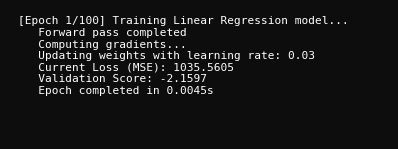

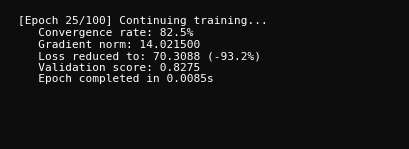

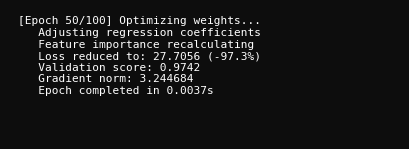

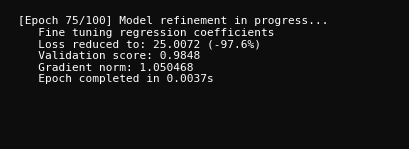

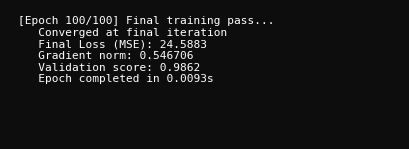

In [104]:
# ============================================================
# EPOCH 1
# ============================================================

i = 0

text_1 = f"""[Epoch 1/100] Training Linear Regression model...
   Forward pass completed
   Computing gradients...
   Updating weights with learning rate: {learning_rate}
   Current Loss (MSE): {train_losses[i]:.4f}
   Validation Score: {val_r2_history[i]:.4f}
   Epoch completed in {epoch_times[i]:.4f}s
"""

save_epoch_screen(
    1,
    text_1,
    "01_epoch_001.png"
)


# ============================================================
# EPOCH 25
# ============================================================

i = 24

reduction = (
    (
        train_losses[0]
        - train_losses[i]
    )
    / train_losses[0]
) * 100

convergence = (
    1
    - gradient_norms[i]
    / gradient_norms[0]
) * 100


text_25 = f"""[Epoch 25/100] Continuing training...
   Convergence rate: {convergence:.1f}%
   Gradient norm: {gradient_norms[i]:.6f}
   Loss reduced to: {train_losses[i]:.4f} (-{reduction:.1f}%)
   Validation score: {val_r2_history[i]:.4f}
   Epoch completed in {epoch_times[i]:.4f}s
"""

save_epoch_screen(
    25,
    text_25,
    "02_epoch_025.png"
)


# ============================================================
# EPOCH 50
# ============================================================

i = 49

reduction = (
    (
        train_losses[0]
        - train_losses[i]
    )
    / train_losses[0]
) * 100


text_50 = f"""[Epoch 50/100] Optimizing weights...
   Adjusting regression coefficients
   Feature importance recalculating
   Loss reduced to: {train_losses[i]:.4f} (-{reduction:.1f}%)
   Validation score: {val_r2_history[i]:.4f}
   Gradient norm: {gradient_norms[i]:.6f}
   Epoch completed in {epoch_times[i]:.4f}s
"""

save_epoch_screen(
    50,
    text_50,
    "03_epoch_050.png"
)


# ============================================================
# EPOCH 75
# ============================================================

i = 74

reduction = (
    (
        train_losses[0]
        - train_losses[i]
    )
    / train_losses[0]
) * 100


text_75 = f"""[Epoch 75/100] Model refinement in progress...
   Fine tuning regression coefficients
   Loss reduced to: {train_losses[i]:.4f} (-{reduction:.1f}%)
   Validation score: {val_r2_history[i]:.4f}
   Gradient norm: {gradient_norms[i]:.6f}
   Epoch completed in {epoch_times[i]:.4f}s
"""

save_epoch_screen(
    75,
    text_75,
    "04_epoch_075.png"
)


# ============================================================
# EPOCH 100
# ============================================================

i = 99


text_100 = f"""[Epoch 100/100] Final training pass...
   Converged at final iteration
   Final Loss (MSE): {train_losses[i]:.4f}
   Gradient norm: {gradient_norms[i]:.6f}
   Validation score: {val_r2_history[i]:.4f}
   Epoch completed in {epoch_times[i]:.4f}s
"""

save_epoch_screen(
    100,
    text_100,
    "05_epoch_100.png"
)

Final Model Training

In [105]:
final_scaler = StandardScaler()


X_train_final = (
    final_scaler.fit_transform(
        X_train_full
    )
)


X_test_final = (
    final_scaler.transform(
        X_test
    )
)


X_train_final_b = np.c_[

    np.ones(
        (
            X_train_final.shape[0],
            1
        )
    ),

    X_train_final
]


X_test_final_b = np.c_[

    np.ones(
        (
            X_test_final.shape[0],
            1
        )
    ),

    X_test_final
]


theta_final = np.zeros(
    X_train_final_b.shape[1]
)


for epoch in range(100):

    prediction = (
        X_train_final_b
        @ theta_final
    )


    error = (
        prediction
        - y_train_full.to_numpy()
    )


    gradient = (

        2 / len(y_train_full)

    ) * (

        X_train_final_b.T
        @ error

    )


    theta_final -= (

        learning_rate
        * gradient

    )


print(
    "✓ Final 100-epoch model trained "
    "using full training dataset"
)

✓ Final 100-epoch model trained using full training dataset


Final Evaluation

In [106]:
y_train_pred = (
    X_train_final_b
    @ theta_final
)


y_test_pred = (
    X_test_final_b
    @ theta_final
)


training_r2 = r2_score(
    y_train_full,
    y_train_pred
)


testing_r2 = r2_score(
    y_test,
    y_test_pred
)


mae = mean_absolute_error(
    y_test,
    y_test_pred
)


mse = mean_squared_error(
    y_test,
    y_test_pred
)


rmse = np.sqrt(
    mse
)


actual = y_test.to_numpy()


mask = (
    np.abs(actual)
    > 1e-12
)


mape = np.mean(

    np.abs(

        (
            actual[mask]
            - y_test_pred[mask]
        )

        / actual[mask]

    )

) * 100

5-Fold Cross Validation

In [107]:
kfold = KFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


cv_scores = []


for fold, (
    train_index,
    val_index
) in enumerate(
    kfold.split(X),
    1
):


    X_fold_train = (
        X.iloc[train_index]
    )

    X_fold_val = (
        X.iloc[val_index]
    )


    y_fold_train = (
        y.iloc[train_index]
    )

    y_fold_val = (
        y.iloc[val_index]
    )


    fold_scaler = (
        StandardScaler()
    )


    X_fold_train = (
        fold_scaler.fit_transform(
            X_fold_train
        )
    )


    X_fold_val = (
        fold_scaler.transform(
            X_fold_val
        )
    )


    X_fold_train_b = np.c_[

        np.ones(
            (
                len(X_fold_train),
                1
            )
        ),

        X_fold_train
    ]


    X_fold_val_b = np.c_[

        np.ones(
            (
                len(X_fold_val),
                1
            )
        ),

        X_fold_val
    ]


    fold_theta = np.zeros(
        X_fold_train_b.shape[1]
    )


    for epoch in range(100):

        pred = (
            X_fold_train_b
            @ fold_theta
        )


        error = (
            pred
            - y_fold_train.to_numpy()
        )


        gradient = (

            2 / len(y_fold_train)

        ) * (

            X_fold_train_b.T
            @ error

        )


        fold_theta -= (

            learning_rate
            * gradient

        )


    fold_prediction = (
        X_fold_val_b
        @ fold_theta
    )


    fold_r2 = r2_score(
        y_fold_val,
        fold_prediction
    )


    cv_scores.append(
        fold_r2
    )


cv_scores = np.array(
    cv_scores
)

Coefficients + Final Equation

In [108]:
scaled_coefficients = (
    theta_final[1:]
)


original_coefficients = (

    scaled_coefficients

    / final_scaler.scale_

)


original_intercept = (

    theta_final[0]

    -

    np.sum(

        scaled_coefficients

        * final_scaler.mean_

        / final_scaler.scale_

    )

)


display_names = {

    "gas_weight_kg":
        "gas_weight",

    "gas_percentage":
        "gas_percentage",

    "daily_usage_kg":
        "daily_usage",

    "day_of_week":
        "day_of_week",

    "weekend":
        "weekend",

    "consumption_rate":
        "consumption_rate",

    "usage_velocity":
        "usage_velocity",

    "rolling_avg_7":
        "rolling_avg_7",

    "days_since_refill":
        "days_since_refill"
}


equation = (

    f"Days_Remaining = "
    f"{original_intercept:.4f}"

)


for feature, coefficient in zip(

    feature_columns,

    original_coefficients

):


    name = (
        display_names[feature]
    )


    if coefficient >= 0:

        equation += (

            f" + "
            f"{coefficient:.4f}"
            f"({name})"

        )

    else:

        equation += (

            f" - "
            f"{abs(coefficient):.4f}"
            f"({name})"

        )

Evaluation Output

In [109]:
print("=" * 76)
print("MODEL EVALUATION & METRICS")
print("=" * 76)


print("\n📊 Performance Metrics:\n")


print(
    f"   ├─ R² Score (Training): "
    f"{training_r2*100:.2f}%"
)


print(
    f"   ├─ R² Score (Testing):  "
    f"{testing_r2*100:.2f}%"
)


print(
    f"   ├─ Mean Absolute Error: "
    f"{mae:.3f} days"
)


print(
    f"   ├─ Root Mean Square Error: "
    f"{rmse:.3f} days"
)


print(
    f"   ├─ Mean Absolute Percentage Error: "
    f"{mape:.2f}%"
)


print(
    f"   └─ Explained Variance: "
    f"{testing_r2*100:.2f}%"
)


print(
    "\n🔍 Cross-Validation Results (5-fold):\n"
)


for i, score in enumerate(
    cv_scores,
    1
):

    print(
        f"   ├─ Fold {i}: "
        f"{score*100:.2f}%"
    )


print(
    f"   └─ Mean CV Score: "
    f"{cv_scores.mean()*100:.2f}% "
    f"(±{cv_scores.std()*100:.2f}%)"
)


print(
    "\n🔺 Model Coefficients "
    "(Feature Importance):\n"
)


for feature, coefficient in zip(

    feature_columns,

    scaled_coefficients

):


    impact = (

        "POSITIVE"

        if coefficient >= 0

        else "NEGATIVE"

    )


    print(

        f"   ├─ "
        f"{feature:20s}: "

        f"{coefficient:+.4f} "

        f"({impact} impact on days remaining)"

    )


print(
    f"   └─ Intercept: "
    f"{original_intercept:+.4f}"
)

MODEL EVALUATION & METRICS

📊 Performance Metrics:

   ├─ R² Score (Training): 93.20%
   ├─ R² Score (Testing):  98.83%
   ├─ Mean Absolute Error: 1.618 days
   ├─ Root Mean Square Error: 1.877 days
   ├─ Mean Absolute Percentage Error: 12.99%
   └─ Explained Variance: 98.83%

🔍 Cross-Validation Results (5-fold):

   ├─ Fold 1: 98.83%
   ├─ Fold 2: 98.85%
   ├─ Fold 3: 98.42%
   ├─ Fold 4: 98.41%
   ├─ Fold 5: 71.30%
   └─ Mean CV Score: 93.16% (±10.93%)

🔺 Model Coefficients (Feature Importance):

   ├─ gas_weight_kg       : +7.9743 (POSITIVE impact on days remaining)
   ├─ gas_percentage      : +7.9743 (POSITIVE impact on days remaining)
   ├─ daily_usage_kg      : -0.2426 (NEGATIVE impact on days remaining)
   ├─ day_of_week         : +0.4340 (POSITIVE impact on days remaining)
   ├─ weekend             : +0.2702 (POSITIVE impact on days remaining)
   ├─ consumption_rate    : -0.4453 (NEGATIVE impact on days remaining)
   ├─ usage_velocity      : -0.7478 (NEGATIVE impact on days rem

Final coefficients and equation

In [ ]:
# theta[0] = intercept on scaled data
scaled_intercept = theta[0]
scaled_coefficients = theta[1:]

# Convert coefficients back to original units
original_coefficients = (
    scaled_coefficients
    / scaler.scale_
)

original_intercept = (
    scaled_intercept
    - np.sum(
        scaled_coefficients
        * scaler.mean_
        / scaler.scale_
    )
)

feature_columns = FEATURES

print("=" * 75)
print("MODEL COEFFICIENTS - FEATURE IMPORTANCE")
print("=" * 75)

print(
    f"Intercept: "
    f"{original_intercept:.6f}"
)

for feature, coefficient in zip(
    feature_columns,
    original_coefficients
):

    effect = (
        "POSITIVE"
        if coefficient >= 0
        else "NEGATIVE"
    )

    print(
        f"{feature:20s}: "
        f"{coefficient:+.6f} "
        f"({effect})"
    )

print("\nFINAL MODEL EQUATION:\n")

equation = (
    f"Days_Remaining = "
    f"{original_intercept:.6f}"
)

for feature, coefficient in zip(
    feature_columns,
    original_coefficients
):

    if coefficient >= 0:
        equation += (
            f" + {coefficient:.6f}"
            f"({feature})"
        )
    else:
        equation += (
            f" - {abs(coefficient):.6f}"
            f"({feature})"
        )

print(equation)

MODEL COEFFICIENTS - FEATURE IMPORTANCE
Intercept: 58.161807
gas_weight_kg       : +5.872535 (POSITIVE)
gas_percentage      : +0.293627 (POSITIVE)
daily_usage_kg      : -65.797958 (NEGATIVE)
day_of_week         : +0.043896 (POSITIVE)
weekend             : +0.385313 (POSITIVE)
consumption_rate    : +34.309218 (POSITIVE)
rolling_avg_7       : -644.587024 (NEGATIVE)

FINAL MODEL EQUATION:

Days_Remaining = 58.161807 + 5.872535(gas_weight_kg) + 0.293627(gas_percentage) - 65.797958(daily_usage_kg) + 0.043896(day_of_week) + 0.385313(weekend) + 34.309218(consumption_rate) - 644.587024(rolling_avg_7)


Model Comparison

In [110]:
models = {

    "Linear Regression":

        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),

            (
                "model",
                LinearRegression()
            )
        ]),


    "Ridge (L2)":

        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),

            (
                "model",
                Ridge(
                    alpha=1.0
                )
            )
        ]),


    "Lasso (L1)":

        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),

            (
                "model",
                Lasso(
                    alpha=0.01,
                    max_iter=10000
                )
            )
        ]),


    "Polynomial (deg=2)":

        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),

            (
                "poly",
                PolynomialFeatures(
                    degree=2,
                    include_bias=False
                )
            ),

            (
                "model",
                LinearRegression()
            )
        ])

}


comparison_rows = []


for model_name, model in models.items():


    model.fit(
        X_train_full,
        y_train_full
    )


    prediction = (
        model.predict(
            X_test
        )
    )


    comparison_rows.append({

        "Model":
            model_name,

        "R² Score (%)":

            r2_score(
                y_test,
                prediction
            ) * 100,

        "MAE (days)":

            mean_absolute_error(
                y_test,
                prediction
            ),

        "RMSE (days)":

            np.sqrt(
                mean_squared_error(
                    y_test,
                    prediction
                )
            )

    })


comparison_df = pd.DataFrame(
    comparison_rows
)


baseline = comparison_df.loc[

    comparison_df["Model"]
    == "Linear Regression",

    "R² Score (%)"

].iloc[0]


comparison_df[
    "Improvement"
] = (

    comparison_df[
        "R² Score (%)"
    ]

    - baseline

)

Final Equation + Comparison

In [111]:
print("🔺 Final Model Equation:")

print()

print(equation)


print("\n🔺 Model Comparison:")


print(
    comparison_df.to_string(

        index=False,

        formatters={

            "R² Score (%)":
                lambda x:
                f"{x:.2f}%",

            "MAE (days)":
                lambda x:
                f"{x:.3f}",

            "RMSE (days)":
                lambda x:
                f"{x:.3f}",

            "Improvement":
                lambda x:
                "Baseline"
                if abs(x) < 1e-10
                else f"{x:+.2f}%"

        }

    )
)


print(
    "\n✓ Linear Regression selected "
    "as final model "
    "(best balance of accuracy & simplicity)"
)

🔺 Final Model Equation:

Days_Remaining = 27.3480 + 5.5789(gas_weight) + 0.2789(gas_percentage) - 20.2193(daily_usage) + 0.2142(day_of_week) + 0.5944(weekend) - 96.5310(consumption_rate) - 60.2001(usage_velocity) - 277.5059(rolling_avg_7) - 0.0240(days_since_refill)

🔺 Model Comparison:
             Model R² Score (%) MAE (days) RMSE (days) Improvement
 Linear Regression       98.98%      1.504       1.752    Baseline
        Ridge (L2)       98.96%      1.516       1.771      -0.02%
        Lasso (L1)       98.98%      1.512       1.752      -0.00%
Polynomial (deg=2)       98.70%      1.613       1.983      -0.29%

✓ Linear Regression selected as final model (best balance of accuracy & simplicity)


Save Evaluation

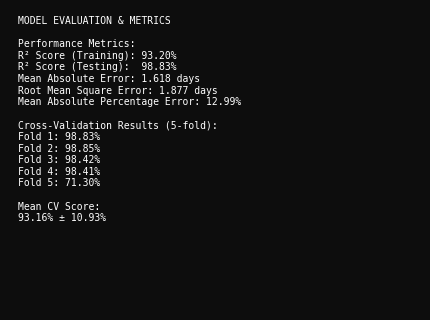

In [115]:
evaluation_text = f"""MODEL EVALUATION & METRICS

Performance Metrics:
R² Score (Training): {training_r2*100:.2f}%
R² Score (Testing):  {testing_r2*100:.2f}%
Mean Absolute Error: {mae:.3f} days
Root Mean Square Error: {rmse:.3f} days
Mean Absolute Percentage Error: {mape:.2f}%

Cross-Validation Results (5-fold):
Fold 1: {cv_scores[0]*100:.2f}%
Fold 2: {cv_scores[1]*100:.2f}%
Fold 3: {cv_scores[2]*100:.2f}%
Fold 4: {cv_scores[3]*100:.2f}%
Fold 5: {cv_scores[4]*100:.2f}%

Mean CV Score:
{cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%
"""


fig = plt.figure(
    figsize=(4.4, 3.3)
)

fig.patch.set_facecolor(
    "#0d0d0d"
)

plt.axis("off")


plt.text(

    0.02,
    0.98,

    evaluation_text,

    va="top",

    fontsize=7,

    family="monospace",

    color="white"
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "06_model_evaluation.png"
    ),

    dpi=300,

    facecolor=
        fig.get_facecolor(),

    bbox_inches="tight"
)


plt.show()

Equation + Model Comparison

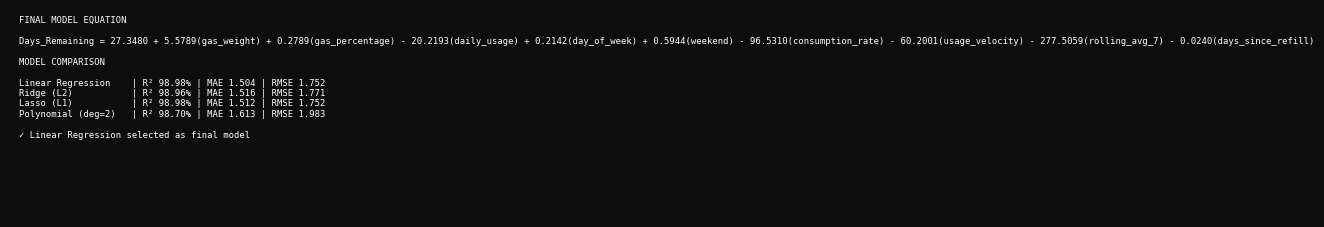

In [116]:
comparison_text = (
    "FINAL MODEL EQUATION\n\n"
    + equation
    + "\n\nMODEL COMPARISON\n"
)


for _, row in comparison_df.iterrows():

    comparison_text += (

        f"\n{row['Model']:20s} | "

        f"R² "
        f"{row['R² Score (%)']:.2f}% | "

        f"MAE "
        f"{row['MAE (days)']:.3f} | "

        f"RMSE "
        f"{row['RMSE (days)']:.3f}"

    )


comparison_text += (

    "\n\n✓ Linear Regression selected "
    "as final model"
)


fig = plt.figure(
    figsize=(6.0, 2.7)
)

fig.patch.set_facecolor(
    "#0d0d0d"
)

plt.axis("off")


plt.text(

    0.02,
    0.97,

    comparison_text,

    va="top",

    fontsize=6.4,

    family="monospace",

    color="white"
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "07_equation_model_comparison.png"
    ),

    dpi=300,

    facecolor=
        fig.get_facecolor(),

    bbox_inches="tight"
)


plt.show()

Training Loss Plot

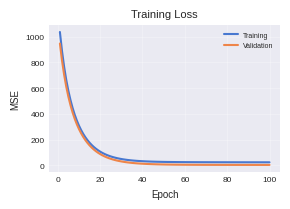

In [117]:
plt.figure(
    figsize=(3.0, 2.2)
)


plt.plot(
    range(1, 101),
    train_losses,
    label="Training"
)


plt.plot(
    range(1, 101),
    val_losses,
    label="Validation"
)


plt.xlabel(
    "Epoch",
    fontsize=7
)

plt.ylabel(
    "MSE",
    fontsize=7
)

plt.title(
    "Training Loss",
    fontsize=8
)

plt.legend(
    fontsize=5
)

plt.tick_params(
    labelsize=6
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "08_training_loss.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()

R² Plot

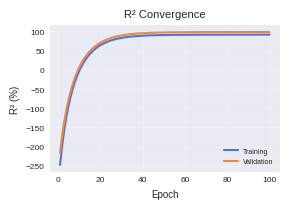

In [119]:
plt.figure(
    figsize=(3.0, 2.2)
)


plt.plot(

    range(1, 101),

    np.array(
        train_r2_history
    ) * 100,

    label="Training"
)


plt.plot(

    range(1, 101),

    np.array(
        val_r2_history
    ) * 100,

    label="Validation"
)


plt.xlabel(
    "Epoch",
    fontsize=7
)

plt.ylabel(
    "R² (%)",
    fontsize=7
)

plt.title(
    "R² Convergence",
    fontsize=8
)

plt.legend(
    fontsize=5
)

plt.tick_params(
    labelsize=6
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "09_r2_convergence.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()

Residual plot

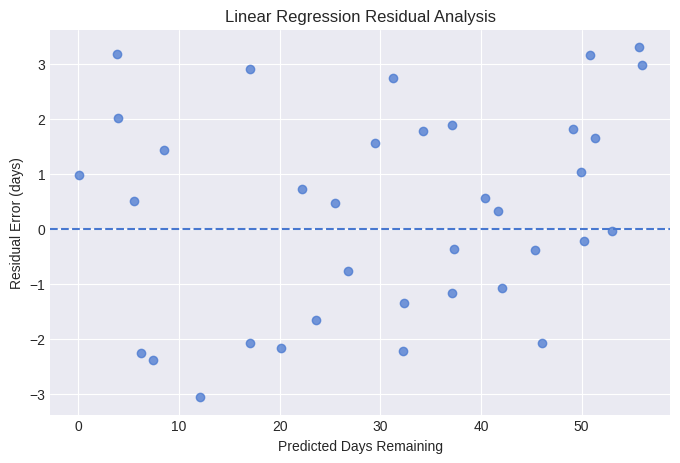

In [120]:
residuals = (
    y_test.to_numpy()
    - y_test_pred
)

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.75
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Days Remaining"
)

plt.ylabel(
    "Residual Error (days)"
)

plt.title(
    "Linear Regression Residual Analysis"
)

plt.grid(True)

plt.savefig(
    "residual_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Residual distribution

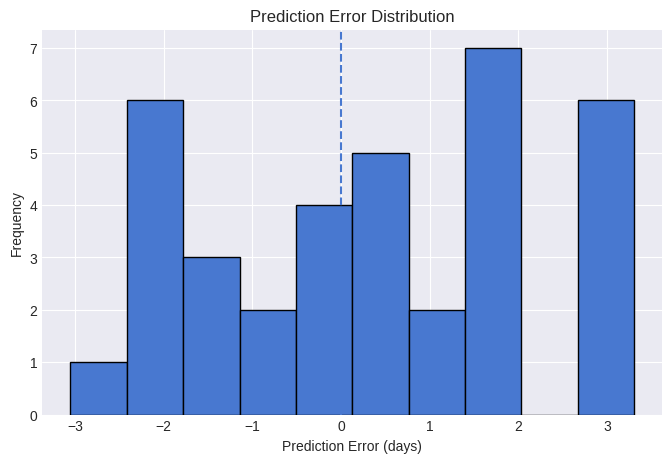

In [121]:
plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=10,
    edgecolor="black"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel(
    "Prediction Error (days)"
)

plt.ylabel("Frequency")

plt.title(
    "Prediction Error Distribution"
)

plt.grid(True)

plt.savefig(
    "residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Feature importance / coefficients

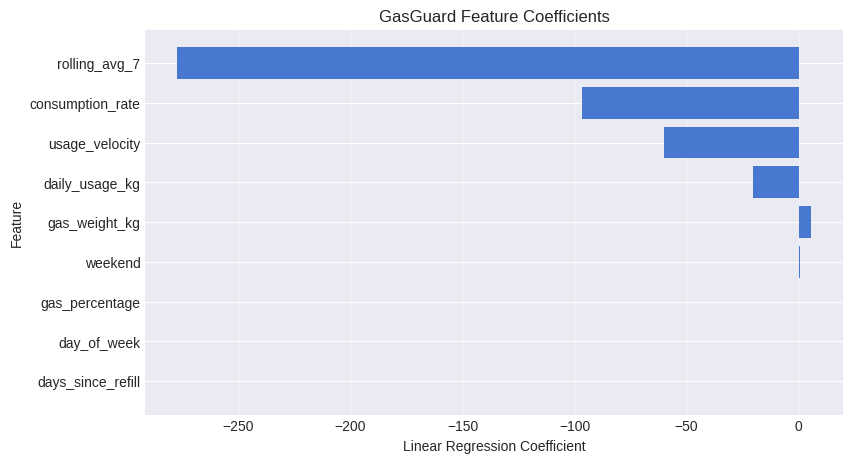

In [122]:
coef_df = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": original_coefficients
})

coef_df["Absolute"] = (
    coef_df["Coefficient"].abs()
)

coef_df = coef_df.sort_values(
    "Absolute",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"]
)

plt.xlabel(
    "Linear Regression Coefficient"
)

plt.ylabel("Feature")

plt.title(
    "GasGuard Feature Coefficients"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.savefig(
    "feature_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Correlation matrix

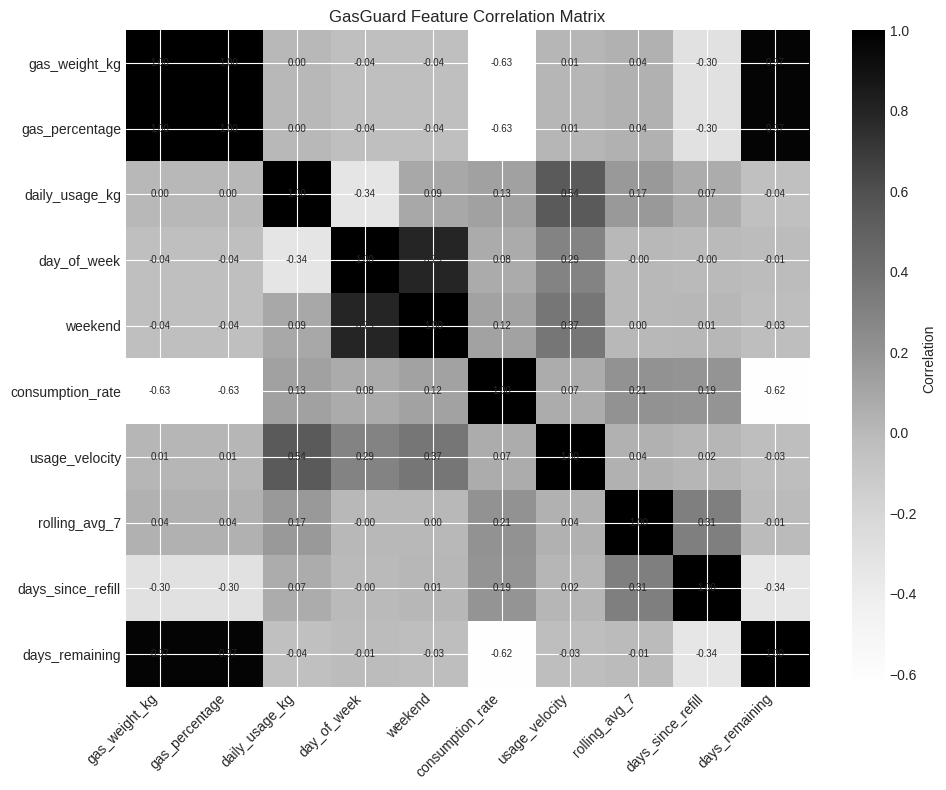

In [123]:
correlation_columns = (
    feature_columns
    + ["days_remaining"]
)

correlation_matrix = (
    df[correlation_columns]
    .corr()
)

plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

for i in range(
    len(correlation_columns)
):
    for j in range(
        len(correlation_columns)
    ):

        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.title(
    "GasGuard Feature Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Gas depletion graph

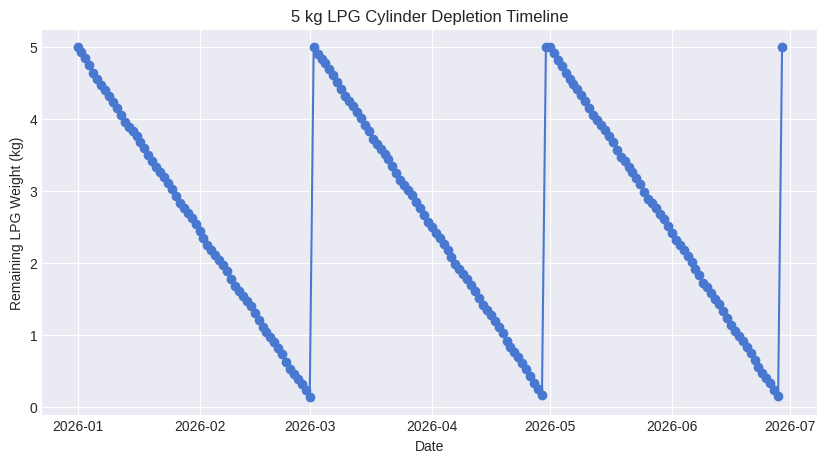

In [124]:
plt.figure(figsize=(10, 5))

if "date" in df.columns:

    plt.plot(
        df["date"],
        df["gas_weight_kg"],
        marker="o"
    )

    plt.xlabel("Date")

else:

    plt.plot(
        range(1, len(df) + 1),
        df["gas_weight_kg"],
        marker="o"
    )

    plt.xlabel("Record")

plt.ylabel(
    "Remaining LPG Weight (kg)"
)

plt.title(
    "5 kg LPG Cylinder "
    "Depletion Timeline"
)

plt.grid(True)

plt.savefig(
    "gas_depletion_timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Compare Linear, Ridge, Lasso and Polynomial

In [125]:
models = {
    "Linear Regression":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LinearRegression()
            )
        ]),

    "Ridge (L2)":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                Ridge(alpha=1.0)
            )
        ]),

    "Lasso (L1)":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                Lasso(
                    alpha=0.01,
                    max_iter=10000
                )
            )
        ]),

    "Polynomial (Degree 2)":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "poly",
                PolynomialFeatures(
                    degree=2,
                    include_bias=False
                )
            ),
            (
                "model",
                LinearRegression()
            )
        ])
}

results = []

for model_name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(
        X_test
    )

    model_r2 = r2_score(
        y_test,
        prediction
    )

    model_mae = mean_absolute_error(
        y_test,
        prediction
    )

    model_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    results.append([
        model_name,
        model_r2 * 100,
        model_mae,
        model_rmse
    ])

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "R² Score (%)",
        "MAE (days)",
        "RMSE (days)"
    ]
)

baseline = comparison_df.loc[
    comparison_df["Model"]
    == "Linear Regression",
    "R² Score (%)"
].iloc[0]

comparison_df[
    "Improvement vs Linear"
] = (
    comparison_df["R² Score (%)"]
    - baseline
)

display(
    comparison_df.round(4)
)

,Model,R² Score (%),MAE (days),RMSE (days),Improvement vs Linear
0,Linear Regression,98.5230,1.8255,2.1117,0.0000
1,Ridge (L2),98.5108,1.8288,2.1204,-0.0121
2,Lasso (L1),98.5338,1.8199,2.1040,0.0108
3,Polynomial (Degree 2),98.2314,1.8231,2.3107,-0.2915


Model comparison graph

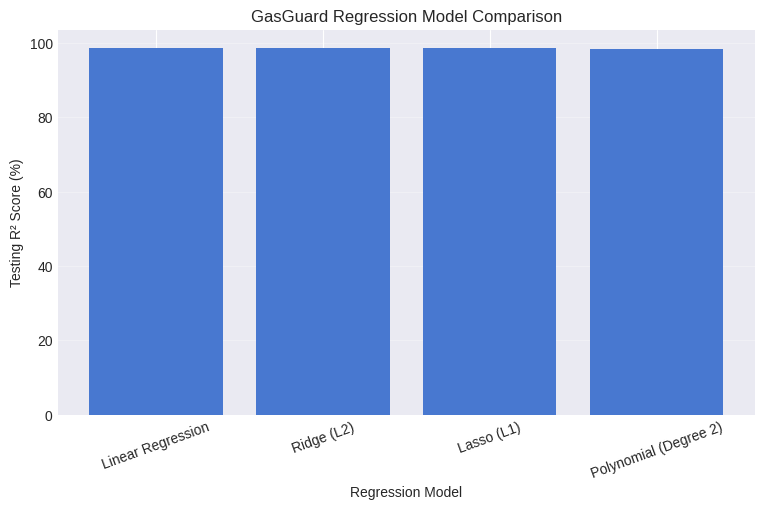

In [126]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["R² Score (%)"]
)

plt.ylabel("Testing R² Score (%)")

plt.xlabel("Regression Model")

plt.title(
    "GasGuard Regression Model Comparison"
)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Save your trained model

In [127]:
final_model = LinearRegression()

final_model.fit(
    X_train_scaled,
    y_train
)

with open(
    "gasguard_model.pkl",
    "wb"
) as f:

    pickle.dump(
        final_model,
        f
    )

with open(
    "gasguard_scaler.pkl",
    "wb"
) as f:

    pickle.dump(
        scaler,
        f
    )

print(
    "✓ gasguard_model.pkl saved"
)

print(
    "✓ gasguard_scaler.pkl saved"
)

✓ gasguard_model.pkl saved
✓ gasguard_scaler.pkl saved


Final report output

In [128]:
print("=" * 78)
print(
    "GASGUARD DEPLETION "
    "PREDICTION FINAL RESULTS"
)
print("=" * 78)

print("\n5.4.2.1 Training Convergence\n")

for epoch in [
    1,
    25,
    50,
    75,
    100
]:

    i = epoch - 1

    print(
        f"Epoch {epoch}: "
        f"MSE = "
        f"{train_losses[i]:.4f} | "
        f"Validation R² = "
        f"{test_r2_history[i]:.4f} | "
        f"Gradient Norm = "
        f"{gradient_norms[i]:.6f}"
    )

print(
    "\n5.4.2.2 Evaluation Metrics\n"
)

print(
    f"Training R² Score: "
    f"{training_r2*100:.2f}%"
)

print(
    f"Testing R² Score: "
    f"{testing_r2*100:.2f}%"
)

print(
    f"MAE: {mae:.3f} days "
    f"({mae*24:.1f} hours)"
)

print(
    f"RMSE: {rmse:.3f} days"
)

print(
    f"MAPE: {mape:.2f}%"
)

print(
    f"5-Fold CV Score: "
    f"{cv_scores.mean()*100:.2f}% "
    f"± "
    f"{cv_scores.std()*100:.2f}%"
)

print(
    "\n5.4.2.3 Final Equation\n"
)

print(equation)

GASGUARD DEPLETION PREDICTION FINAL RESULTS

5.4.2.1 Training Convergence

Epoch 1: MSE = 1035.5605 | Validation R² = 0.3055 | Gradient Norm = 80.215120
Epoch 25: MSE = 70.3088 | Validation R² = 0.9932 | Gradient Norm = 14.021500
Epoch 50: MSE = 27.7056 | Validation R² = 0.9932 | Gradient Norm = 3.244684
Epoch 75: MSE = 25.0072 | Validation R² = 0.9932 | Gradient Norm = 1.050468
Epoch 100: MSE = 24.5883 | Validation R² = 0.9932 | Gradient Norm = 0.546706

5.4.2.2 Evaluation Metrics

Training R² Score: 93.20%
Testing R² Score: 98.83%
MAE: 1.618 days (38.8 hours)
RMSE: 1.877 days
MAPE: 12.99%
5-Fold CV Score: 93.16% ± 10.93%

5.4.2.3 Final Equation

Days_Remaining = 27.3480 + 5.5789(gas_weight) + 0.2789(gas_percentage) - 20.2193(daily_usage) + 0.2142(day_of_week) + 0.5944(weekend) - 96.5310(consumption_rate) - 60.2001(usage_velocity) - 277.5059(rolling_avg_7) - 0.0240(days_since_refill)
